In [39]:
import pandas as pd
import numpy as np
char_pop = pd.read_excel('BBA amyloid amostras liquor - base - com sexo idade biomarcadores e MMSE Lisboa e Coimbra ENVIADO.xlsx')

In [4]:
char_pop["cohort"] = char_pop["Code"].apply(
    lambda x: "Lisbon" if str(x).startswith("LIS") else "Coimbra"
)

In [5]:
char_pop

,Code,BBA,MCIAD=1 control=0,idade,sexo,CSF data tTau,CSF data pTau,CSF data abeta42,Schooling,MMSE,comentários,cohort
0,LIS-008,BBA+,1.0,63,F,200,26.0,324.0,4.0,22,NaN,Lisbon
1,LIS-011,BBA+,1.0,59,F,540,74.0,504.0,16.0,24,NaN,Lisbon
2,LIS-001,BBA+,1.0,76,F,618,95.0,552.0,16.0,27,NaN,Lisbon
3,LIS-017,BBA normal,0.0,44,F,197,31.0,767.0,16.0,30,NaN,Lisbon
4,LIS-031,BBA+,1.0,67,F,892,117.0,512.0,11.0,21,NaN,Lisbon
...,...,...,...,...,...,...,...,...,...,...,...,...
131,109901,Abeta-Positivo,1.0,62,M,608,120.2,401.0,NaN,ND,NaN,Coimbra
132,110073,Abeta-Negativo,0.0,46,M,190,29.8,1157.0,NaN,ND,NaN,Coimbra
133,110203,Abeta-Negativo,0.0,54,F,238,30.4,1335.0,NaN,ND,NaN,Coimbra
134,110404,Abeta-Negativo,0.0,43,F,83,15.7,719.0,NaN,29,NaN,Coimbra


In [10]:
char_pop.columns

Index(['Code', 'BBA', 'MCIAD=1 control=0', 'idade ', 'sexo', 'CSF data tTau',
       'CSF data pTau', 'CSF data abeta42', 'Schooling', 'MMSE', 'comentários',
       'cohort'],
      dtype='object')

In [12]:
char_pop = char_pop.rename(columns={
    "Code": "patient_id",
    "idade ": "age",
    "sexo": "sex",
    "CSF data tTau": "tTau",
    "CSF data pTau": "pTau",
    "CSF data abeta42": "abeta42",
    "Schooling": "schooling",
    "MCIAD=1 control=0": "diagnosis",
    "comentários": "comments",
    "BBA": "bba_status"
})

In [14]:
data_log2_Coimbra = pd.read_pickle('data_log2_Coimbra_threshold.pkl')
data_log2_LC = pd.read_pickle('data_log2_Lisbon_Coimbra_threshold.pkl')
data_log2_Lisbon = pd.read_pickle('data_log2_Lisbon_threshold.pkl')

In [20]:
char_pop["patient_id_clean"] = (
    char_pop["patient_id"]
    .astype(str)
    .str.replace("-", "", regex=False)
    .str.strip()
)

In [22]:
char_pop['patient_id_clean']

0      LIS008
1      LIS011
2      LIS001
3      LIS017
4      LIS031
        ...  
131    109901
132    110073
133    110203
134    110404
135    110579
Name: patient_id_clean, Length: 136, dtype: object

In [25]:
cluster_ids = (
    data_log2_LC.index
    .astype(str)
    .str.replace("-", "", regex=False)
    .str.strip()
)

In [27]:
char_pop_filtered = char_pop[
    char_pop["patient_id_clean"].isin(cluster_ids)
]

## Cohort Characterization

To characterize the study population, clinical and demographic information from the Lisbon and Coimbra cohorts was integrated into a unified analytical dataset. A cohort label was assigned to each patient based on the patient identifier.

Only subjects retained after preprocessing and quality control steps were included in the characterization analysis, ensuring consistency with downstream clustering and subtype analyses.

Column names were standardized to improve readability and facilitate downstream analyses. Clinical variables included:
- age
- sex
- years of education
- MMSE

CSF biomarkers included:
- Aβ42
- total Tau (tTau)
- phosphorylated Tau (pTau)

Missing or non-numeric values were manually curated. In particular, "ND" values in MMSE were converted to missing values (`NaN`), while biomarker values exceeding the assay upper detection threshold (e.g., `>1200`) were capped at the maximum measurable value.

Biological classification labels originating from the two cohorts were harmonized into a unified biomarker status variable:
- Positive
- Negative
- Intermediate

Descriptive statistics and visualization analyses were then performed to assess demographic, clinical, and biomarker characteristics across cohorts.

In [30]:
char_pop_filtered.groupby("cohort")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
cohort,,,,,,,,
Coimbra,57.0,62.508772,9.212032,42.0,57.00,63.0,70.0,80.0
Lisbon,68.0,66.970588,8.423440,44.0,61.75,68.5,73.0,79.0


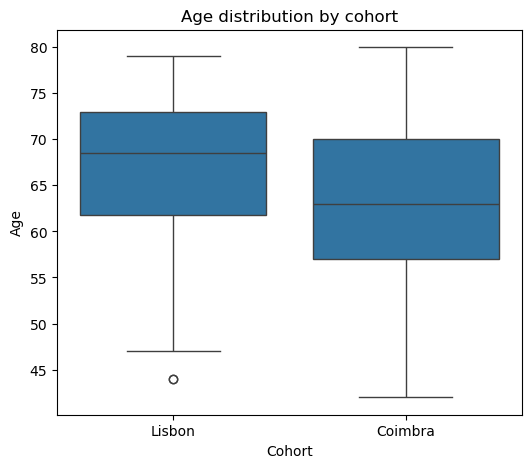

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.boxplot(
    data=char_pop_filtered,
    x="cohort",
    y="age"
)

plt.title("Age distribution by cohort")
plt.ylabel("Age")
plt.xlabel("Cohort")

plt.show()

In [32]:
pd.crosstab(
    char_pop_filtered["cohort"],
    char_pop_filtered["sex"]
)

sex,F,M
cohort,,
Coimbra,38,19
Lisbon,38,30


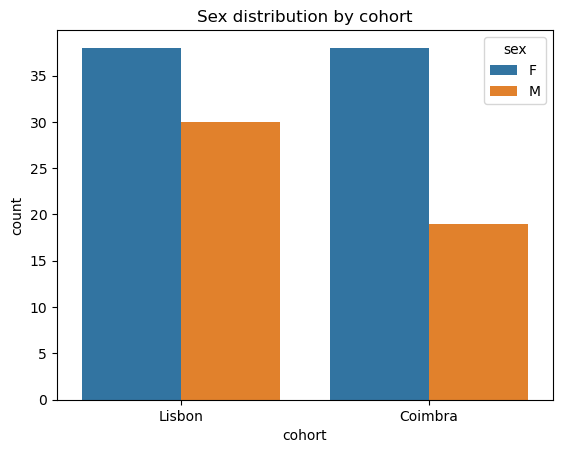

In [33]:
sns.countplot(
    data=char_pop_filtered,
    x="cohort",
    hue="sex"
)

plt.title("Sex distribution by cohort")
plt.show()

In [40]:
char_pop_filtered["MMSE"] = (
    char_pop_filtered["MMSE"]
    .replace("ND", np.nan)
)
char_pop_filtered["MMSE"] = pd.to_numeric(
    char_pop_filtered["MMSE"]
)

In [41]:
char_pop_filtered.groupby("cohort")["MMSE"].describe()

,count,mean,std,min,25%,50%,75%,max
cohort,,,,,,,,
Coimbra,44.0,26.613636,2.233111,21.0,25.0,27.0,28.0,30.0
Lisbon,56.0,26.035714,2.536743,21.0,24.0,26.0,28.0,30.0


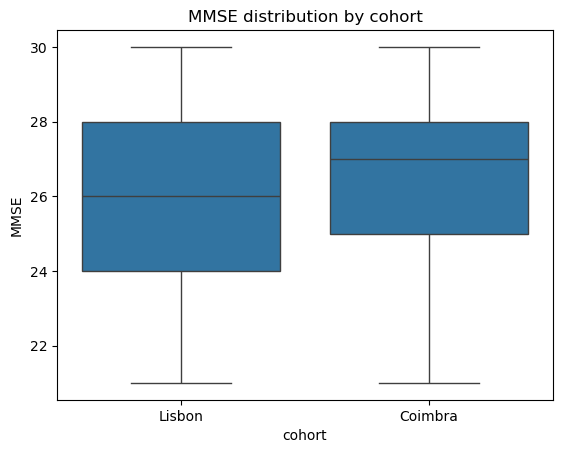

In [44]:
sns.boxplot(
    data=char_pop_filtered,
    x="cohort",
    y="MMSE"
)

plt.title("MMSE distribution by cohort")
plt.show()

In [57]:
char_pop_filtered.groupby("cohort")["schooling"].describe()

,count,mean,std,min,25%,50%,75%,max
cohort,,,,,,,,
Coimbra,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lisbon,57.0,12.736842,3.893797,2.0,10.0,14.0,16.0,17.0


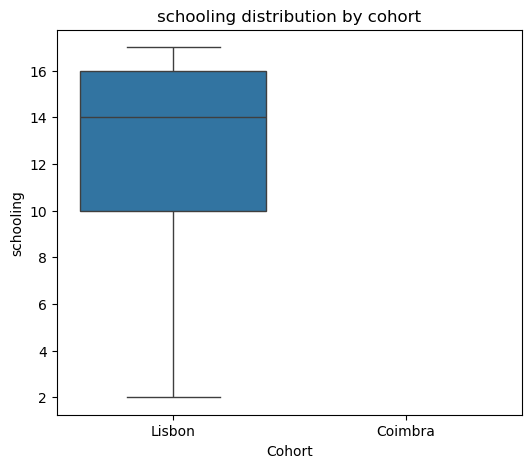

In [56]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=char_pop_filtered,
    x="cohort",
    y="schooling"
)

plt.title("schooling distribution by cohort")
plt.ylabel("schooling")
plt.xlabel("Cohort")

plt.show()

In [50]:
char_pop_filtered.groupby("cohort")["abeta42"].describe()

,count,mean,std,min,25%,50%,75%,max
cohort,,,,,,,,
Coimbra,57.0,809.632368,347.805218,303.03,516.00,787.2,1073.287671,1584.898519
Lisbon,68.0,621.573529,243.183569,273.00,459.75,555.0,700.000000,1260.000000


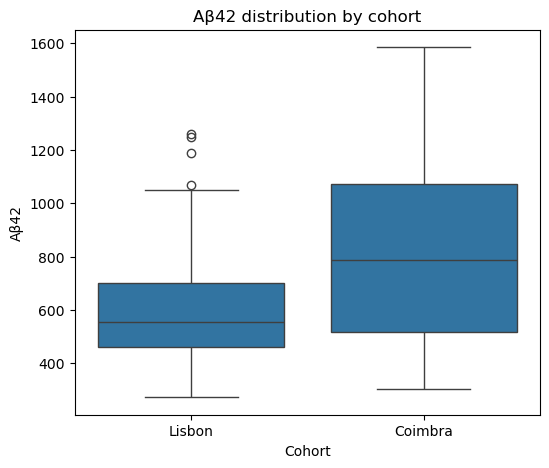

In [51]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=char_pop_filtered,
    x="cohort",
    y="abeta42"
)

plt.title("Aβ42 distribution by cohort")
plt.ylabel("Aβ42")
plt.xlabel("Cohort")

plt.show()

In [61]:
char_pop_filtered.columns

Index(['patient_id', 'bba_status', 'diagnosis', 'age', 'sex', 'tTau', 'pTau',
       'abeta42', 'schooling', 'MMSE', 'comments', 'cohort',
       'patient_id_clean'],
      dtype='object')

In [62]:
char_pop_filtered.groupby("cohort")["pTau"].describe()

,count,mean,std,min,25%,50%,75%,max
cohort,,,,,,,,
Coimbra,57.0,54.215145,43.869960,15.7,28.90,35.97,58.2,221.1
Lisbon,68.0,68.764706,37.069164,16.0,37.75,62.00,98.5,165.0


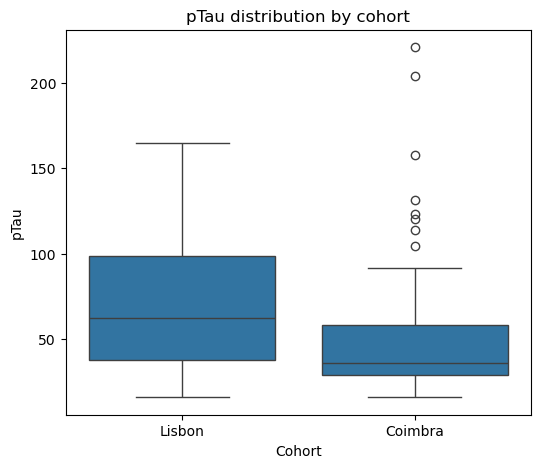

In [63]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=char_pop_filtered,
    x="cohort",
    y="pTau"
)

plt.title("pTau distribution by cohort")
plt.ylabel("pTau")
plt.xlabel("Cohort")

plt.show()

In [71]:
char_pop_filtered["tTau"] = (
    char_pop_filtered["tTau"]
    .replace(">1200", 1200)
)

char_pop_filtered["tTau"] = pd.to_numeric(
    char_pop_filtered["tTau"]
)

In [72]:
char_pop_filtered.groupby("cohort")["tTau"].describe()

,count,mean,std,min,25%,50%,75%,max
cohort,,,,,,,,
Coimbra,57.0,359.450237,292.174872,83.0,164.9,238.0,463.4,1347.0
Lisbon,68.0,578.205882,420.542633,119.0,273.0,469.5,767.0,1850.0


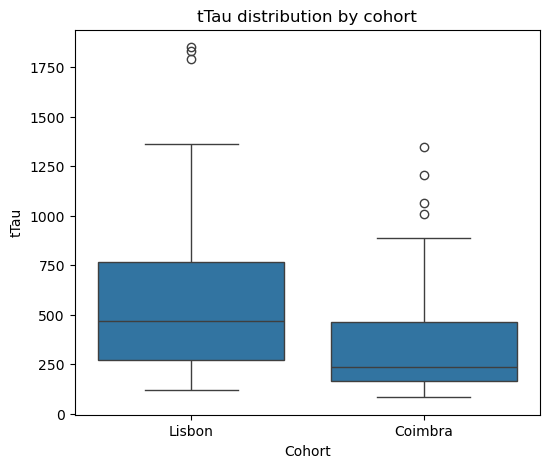

In [112]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=char_pop_filtered,
    x="cohort",
    y="tTau"
)

plt.title("tTau distribution by cohort")
plt.ylabel("tTau")
plt.xlabel("Cohort")

plt.show()

In [73]:
pd.crosstab(
    char_pop_filtered["cohort"],
    char_pop_filtered["diagnosis"]
)

diagnosis,0.0,1.0
cohort,,
Coimbra,35,22
Lisbon,22,45


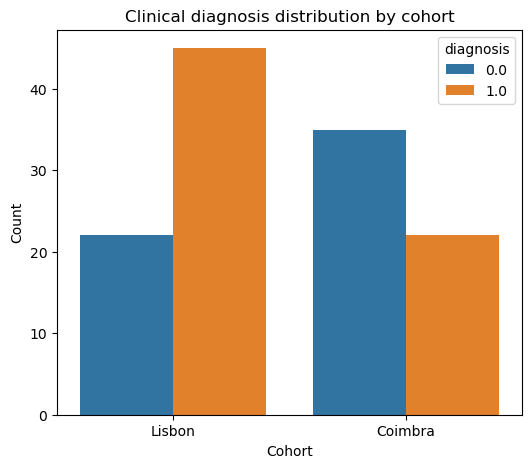

In [74]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=char_pop_filtered,
    x="cohort",
    hue="diagnosis"
)

plt.title("Clinical diagnosis distribution by cohort")
plt.xlabel("Cohort")
plt.ylabel("Count")

plt.show()

In [75]:
pd.crosstab(
    char_pop_filtered["cohort"],
    char_pop_filtered["bba_status"]
)

bba_status,Abeta-Negativo,Abeta-Positivo,BBA ?,BBA normal,BBA+
cohort,,,,,
Coimbra,35,22,0,0,0
Lisbon,0,0,1,22,45


In [77]:
char_pop_filtered["bba_status"] = (
    char_pop_filtered["bba_status"]
    .replace({
        "Abeta-Positivo": "Positive",
        "BBA+": "Positive",

        "Abeta-Negativo": "Negative",
        "BBA normal": "Negative",

        "BBA ?": "Intermediate"
    })
)

In [78]:
pd.crosstab(
    char_pop_filtered["cohort"],
    char_pop_filtered["bba_status"]
)

bba_status,Intermediate,Negative,Positive
cohort,,,
Coimbra,0,35,22
Lisbon,1,22,45


In [85]:
char_pop_filtered[
    char_pop_filtered["bba_status"] == "Intermediate"
]

,patient_id,bba_status,diagnosis,age,sex,tTau,pTau,abeta42,schooling,MMSE,comments,cohort,patient_id_clean
61,LIS-098,Intermediate,NaN,70,F,291.0,33.0,977.0,16.0,29.0,excluir DFT,Lisbon,LIS098


In [80]:
pd.crosstab(
    char_pop_filtered["cohort"],
    char_pop_filtered["diagnosis"]
)

diagnosis,0.0,1.0
cohort,,
Coimbra,35,22
Lisbon,22,45


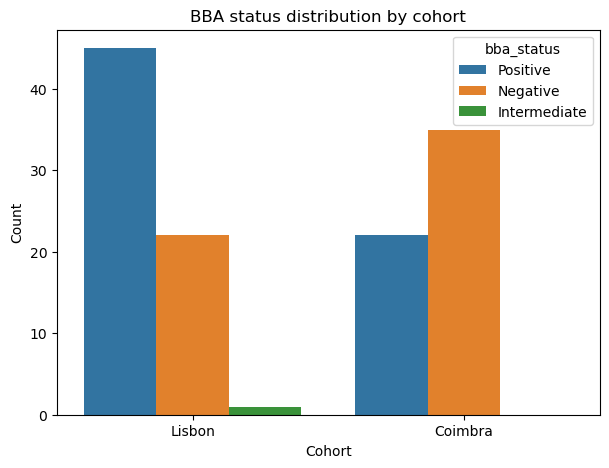

In [86]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=char_pop_filtered,
    x="cohort",
    hue="bba_status"
)

plt.title("BBA status distribution by cohort")
plt.xlabel("Cohort")
plt.ylabel("Count")

plt.show()

## Distribution Assessment

Before performing statistical comparisons between cohorts, the distribution of continuous variables was assessed. This step is essential to determine whether parametric or non-parametric statistical tests are more appropriate.

Variables evaluated included:
- age
- years of education
- MMSE
- Aβ42
- tTau
- pTau

Distribution inspection also provides important biological insights into cohort heterogeneity, variability, and the presence of potential outliers or subgroup structures. In particular, biomarker distributions may reveal differences in disease severity and biological heterogeneity between the Lisbon and Coimbra cohorts.

Kernel density estimation (KDE) plots and violin plots were used to visually inspect the distribution shape, skewness, dispersion, and potential multimodality of each variable.

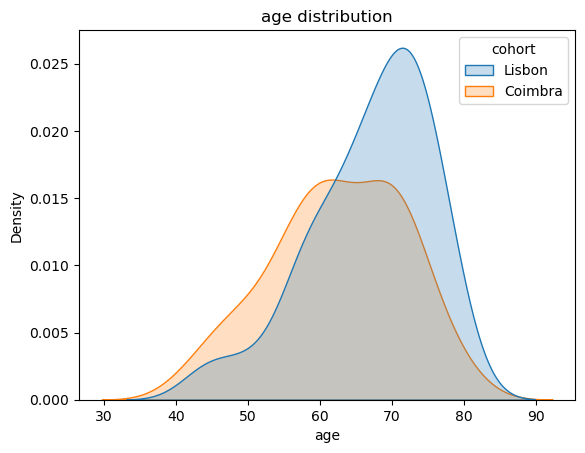

In [89]:
sns.kdeplot(
    data=char_pop_filtered,
    x="age",
    hue="cohort",
    fill=True
)

plt.title("age distribution")
plt.show()

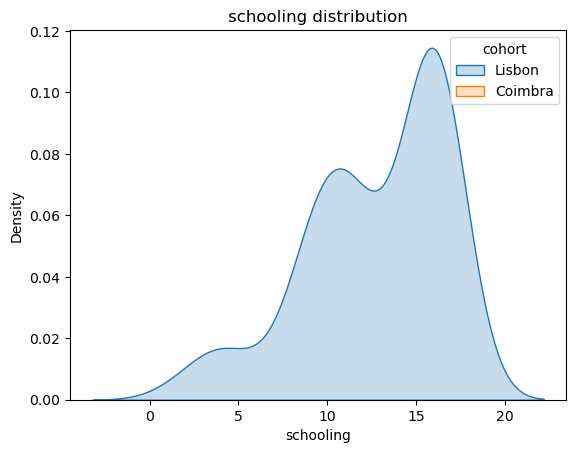

In [90]:
sns.kdeplot(
    data=char_pop_filtered,
    x="schooling",
    hue="cohort",
    fill=True
)

plt.title("schooling distribution")
plt.show()

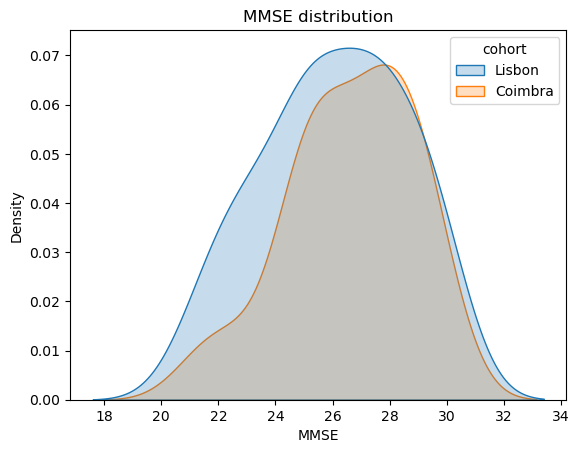

In [88]:
sns.kdeplot(
    data=char_pop_filtered,
    x="MMSE",
    hue="cohort",
    fill=True
)

plt.title("MMSE distribution")
plt.show()


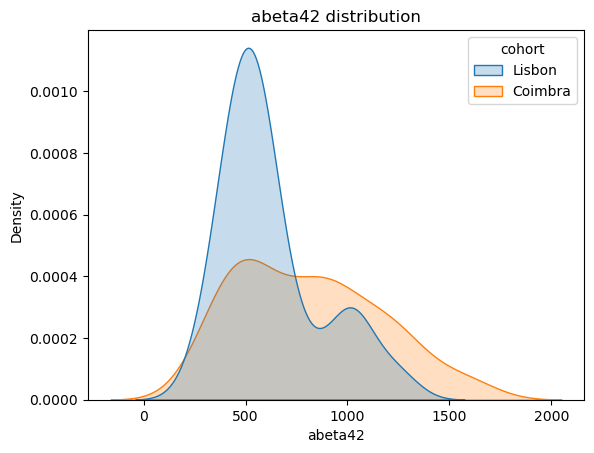

In [91]:
sns.kdeplot(
    data=char_pop_filtered,
    x="abeta42",
    hue="cohort",
    fill=True
)

plt.title("abeta42 distribution")
plt.show()


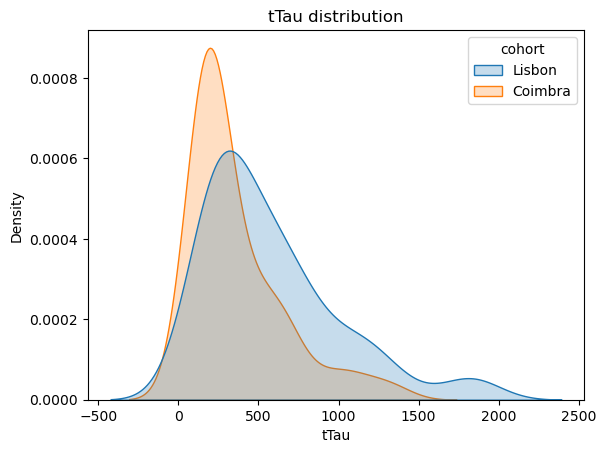

In [92]:
sns.kdeplot(
    data=char_pop_filtered,
    x="tTau",
    hue="cohort",
    fill=True
)

plt.title("tTau distribution")
plt.show()


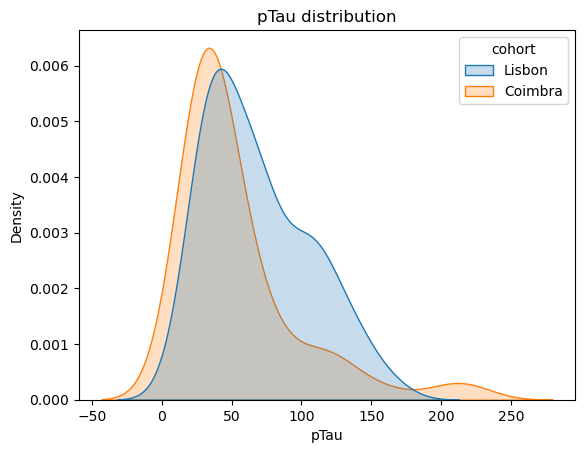

In [93]:
sns.kdeplot(
    data=char_pop_filtered,
    x="pTau",
    hue="cohort",
    fill=True
)

plt.title("pTau distribution")
plt.show()


## Statistical Strategy

Continuous variables were compared between cohorts using the Mann–Whitney U test. Although some variables, such as age, showed approximately unimodal distributions, several clinical and biomarker variables displayed non-Gaussian characteristics, including skewness and dispersion differences between cohorts.

A non-parametric approach was therefore selected to provide a robust and consistent statistical framework across all continuous variables, including:
- age
- years of education
- MMSE
- Aβ42
- tTau
- pTau

Categorical variables, including sex, diagnosis, and biomarker status classification, were evaluated using chi-square tests (or Fisher’s exact test when appropriate).

In [114]:
from scipy.stats import mannwhitneyu

variables = [
    "age",
    "MMSE",
    "abeta42",
    "tTau",
    "pTau"
]

for var in variables:

    lisbon = char_pop_filtered[
        char_pop_filtered["cohort"] == "Lisbon"
    ][var].dropna()

    coimbra = char_pop_filtered[
        char_pop_filtered["cohort"] == "Coimbra"
    ][var].dropna()

    stat, p = mannwhitneyu(
        lisbon,
        coimbra,
        alternative="two-sided"
    )

    print(f"{var}")
    print(f"U statistic = {stat:.3f}")
    print(f"p-value = {p:.5f}")
    print("-" * 30)

age
U statistic = 2520.000
p-value = 0.00392
------------------------------
MMSE
U statistic = 1070.000
p-value = 0.25824
------------------------------
abeta42
U statistic = 1364.000
p-value = 0.00447
------------------------------
tTau
U statistic = 2727.000
p-value = 0.00009
------------------------------
pTau
U statistic = 2587.000
p-value = 0.00131
------------------------------


In [110]:
sex_table = pd.crosstab(
    char_pop_filtered["cohort"],
    char_pop_filtered["sex"]
)

print(sex_table)

sex       F   M
cohort         
Coimbra  38  19
Lisbon   38  30


In [107]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(sex_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"p-value: {p:.5f}")


Chi-square statistic: 1.094
p-value: 0.29549


In [109]:
diag_table = pd.crosstab(
    char_pop_filtered["cohort"],
    char_pop_filtered["diagnosis"]
)

print(diag_table)

diagnosis  0.0  1.0
cohort             
Coimbra     35   22
Lisbon      22   45


In [111]:
chi2, p, dof, expected = chi2_contingency(diag_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"p-value: {p:.5f}")

Chi-square statistic: 9.002
p-value: 0.00270
